# ExtractFeature,CNN

### Library

In [ ]:
! pip install mne

In [ ]:
# IMPORT LIBRARY
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as scs
import re
from numpy import genfromtxt
import scipy.fftpack
import math as m
np.random.seed(0)
import scipy.io
from sklearn.decomposition import PCA
from scipy.interpolate import griddata
from sklearn.preprocessing import scale
import mne
from scipy import signal
import glob
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler,label_binarize
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from imblearn.over_sampling import RandomOverSampler
import torchvision.transforms as transforms
from sklearn.metrics import roc_auc_score, f1_score,classification_report,confusion_matrix,roc_curve, auc

In [ ]:
def augment_EEG(data, stdMult, pca=False, n_components=2):
    """
    Augment data by adding normal noise to each feature.

    :param data: EEG feature data as a matrix (n_samples x n_features)
    :param stdMult: Multiplier for std of added noise
    :param pca: if True will perform PCA on data and add noise proportional to PCA components.
    :param n_components: Number of components to consider when using PCA.
    :return: Augmented data as a matrix (n_samples x n_features)
    """
    augData = np.zeros(data.shape)
    if pca:
        pca = PCA(n_components=n_components)
        pca.fit(data)
        components = pca.components_
        variances = pca.explained_variance_ratio_
        coeffs = np.random.normal(scale=stdMult, size=pca.n_components) * variances
        for s, sample in enumerate(data):
            augData[s, :] = sample + (components * coeffs.reshape((n_components, -1))).sum(axis=0)
    else:
        # Add Gaussian noise with std determined by weighted std of each feature
        for f, feat in enumerate(data.transpose()):
            augData[:, f] = feat + np.random.normal(scale=stdMult*np.std(feat), size=feat.size)
    return augData

def gen_images(locs, features, n_gridpoints, normalize=True,
               augment=False, pca=False, std_mult=0.1, n_components=2, edgeless=False):
    """
    Generates EEG images given electrode locations in 2D space and multiple feature values for each electrode

    :param locs: An array with shape [n_electrodes, 2] containing X, Y
                        coordinates for each electrode.
    :param features: Feature matrix as [n_samples, n_features]
                                Features are as columns.
                                Features corresponding to each frequency band are concatenated.
                                (alpha1, alpha2, ..., beta1, beta2,...)
    :param n_gridpoints: Number of pixels in the output images
    :param normalize:   Flag for whether to normalize each band over all samples
    :param augment:     Flag for generating augmented images
    :param pca:         Flag for PCA based data augmentation
    :param std_mult     Multiplier for std of added noise
    :param n_components: Number of components in PCA to retain for augmentation
    :param edgeless:    If True generates edgeless images by adding artificial channels
                        at four corners of the image with value = 0 (default=False).
    :return:            Tensor of size [samples, colors, W, H] containing generated
                        images.
    """
    feat_array_temp = []
    nElectrodes = locs.shape[0]     # Number of electrodes

    # Test whether the feature vector length is divisible by number of electrodes
    assert features.shape[1] % nElectrodes == 0
    n_colors = features.shape[1] / nElectrodes
    for c in range(int(n_colors)):
        feat_array_temp.append(features[:, c * nElectrodes : nElectrodes * (c+1)])
    if augment:
        if pca:
            for c in range(int(n_colors)):
                feat_array_temp[c] = augment_EEG(feat_array_temp[c], std_mult, pca=True, n_components=n_components)
        else:
            for c in range(int(n_colors)):
                feat_array_temp[c] = augment_EEG(feat_array_temp[c], std_mult, pca=False, n_components=n_components)
    n_samples = features.shape[0]

    # Interpolate the values
    grid_x, grid_y = np.mgrid[
                     min(locs[:, 0]):max(locs[:, 0]):n_gridpoints*1j,
                     min(locs[:, 1]):max(locs[:, 1]):n_gridpoints*1j
                     ]
    temp_interp = []
    for c in range(int(n_colors)):
        temp_interp.append(np.zeros([n_samples, n_gridpoints, n_gridpoints]))

    # Generate edgeless images
    if edgeless:
        min_x, min_y = np.min(locs, axis=0)
        max_x, max_y = np.max(locs, axis=0)
        locs = np.append(locs, np.array([[min_x, min_y], [min_x, max_y], [max_x, min_y], [max_x, max_y]]), axis=0)
        for c in range(n_colors):
            feat_array_temp[c] = np.append(feat_array_temp[c], np.zeros((n_samples, 4)), axis=1)

    # Interpolating
    for i in range(n_samples):
        for c in range(int(n_colors)):
            temp_interp[c][i, :, :] = griddata(locs, feat_array_temp[c][i, :], (grid_x, grid_y),
                                               method='cubic', fill_value=0)
        print('Interpolating {0}/{1}\r'.format(i + 1, n_samples), end='\r')

    # Normalizing
    for c in range(int(n_colors)):
        if normalize:
            temp_interp[c][~np.isnan(temp_interp[c])] = \
                scale(temp_interp[c][~np.isnan(temp_interp[c])])
        temp_interp[c] = np.nan_to_num(temp_interp[c])
    return np.swapaxes(np.asarray(temp_interp), 0, 1)


In [ ]:
def get_fft(snippet, sampling_rate=128.0):
    """
    Compute FFT (Fast Fourier Transform) and return frequencies (frq) and spectrum magnitude (magnitude).

    Parameters:
    - snippet: Input signal (1D array).
    - sampling_rate: Sampling frequency (Hz), default is 128 Hz.

    Returns:
    - frq: Array of frequencies (in Hz).
    - magnitude: Corresponding spectrum magnitude.
    """

    n = len(snippet)

    k = np.arange(n)
    T = n / sampling_rate
    frq = k / T
    frq = frq[:n // 2]

    Y = np.fft.fft(snippet) / n
    magnitude = np.abs(Y[:n // 2])

    return frq, magnitude



def waves_averages(f,Y):
    theta_range = (0.2,7)
    alpha_range = (8,13)
    beta_range = (16,31)
    gamma_range=(32,100)
    delta_range=(0.2,3)
    theta = Y[(f>theta_range[0]) & (f<=theta_range[1])].mean()
    alpha = Y[(f>alpha_range[0]) & (f<=alpha_range[1])].mean()
    beta = Y[(f>beta_range[0]) & (f<=beta_range[1])].mean()
    gamma=Y[(f>gamma_range[0]) & (f<=gamma_range[1])].mean()
    delta=Y[(f>delta_range[0]) & (f<=delta_range[1])].mean()
    return theta,alpha,beta

def make_steps(samples,frame_duration,overlap):
    '''
    in:
    samples - number of samples in the session
    frame_duration - frame duration in seconds
    overlap - float fraction of frame to overlap in range (0,1)

    out: list of tuple ranges
    '''

    Fs = 128
    i = 0
    intervals = []
    samples_per_frame = Fs * frame_duration
    while i+samples_per_frame <= samples:
        intervals.append((i,i+samples_per_frame))
        i = i + samples_per_frame - int(samples_per_frame*overlap)
    return intervals

def make_frames(df, frame_duration, overlap):
    """
    Create frames from EEG data, calculating theta, alpha, and beta averages for each frame.

    :param df: DataFrame with EEG data (rows: time points, columns: channels).
    :param frame_duration: Duration of each frame in seconds.
    :param overlap: Overlap between consecutive frames as a fraction (e.g., 0.3 for 30% overlap).
    :return: NumPy array of shape (n_frames, n_channels, 3), where 3 represents theta, alpha, and beta bands.
    """
    Fs = 128.0
    frame_length = int(Fs * frame_duration)
    steps = make_steps(len(df), frame_duration, overlap)

    frames = []

    for start, end in steps:
        frame = []
        for channel in df.columns:

            snippet = np.array(df.loc[start:end, channel])

            f, Y = get_fft(snippet)
            theta,alpha, beta = waves_averages(f, Y)
            frame.append([theta,alpha, beta])

        frames.append(frame)

    return np.array(frames)

def make_epochs(X,window_size=128, bridge=90):
    epochs = []
    num_rows=len(X)
    for start in range(0, num_rows, bridge):
        end = start + window_size
        if end > num_rows:
            end = num_rows
        epochs.append(X[start:end])

    print(f"Number of epochs: {len(epochs)}")
    return epochs

def make_data_pipeline(df, image_size, frame_duration, overlap, locs_2d,output_dir,filename):
    '''
    IN:
    param df: DataFrame containing the data.
    param image_size: The output size of the image (x, x).
    param frame_duration: Duration of each frame in seconds.
    param overlap: Percentage of overlap between frames (0 to 1).
    param locs_2d: 2D coordinates of channels used for creating images.

    OUT:
    X: A numpy array containing the image frames (unshuffled),
       where:
       - Red: Theta band.
       - Green: Alpha band.
       - Blue: Beta band.
    y: A numpy array containing the corresponding labels (1 or 0).

    '''
    state_encode = {
        '1': 0,
        '2': 1,
        '0': 2
    }

    list_state = df['state'].unique()

    X_list, y_list = [], []

    for state in list_state:

        new_df = df[(df['state'] == state)].reset_index(drop=True)

        columns_to_drop = ['state','AF3','AF4']
        existing_columns = [col for col in columns_to_drop if col in new_df.columns]
        new_df = new_df.drop(columns=existing_columns)


        label = state_encode[str(state)]

        X_0 = make_frames(new_df, frame_duration, overlap)

        X_1 = X_0.reshape(len(X_0), 12 * 3)
        images = gen_images(np.array(locs_2d), X_1, image_size, normalize=True,pca=True,augment=True)
        images = np.swapaxes(images, 1, 3)

        print(len(images), ' frames generated with label ', label, '.\n')

        X_list.append(images)
        y_list.append(np.ones(len(images)) * label)

    X = np.concatenate(X_list, axis=0) if X_list else np.array([])
    y = np.concatenate(y_list, axis=0) if y_list else np.array([])
    np.savez(output_dir+filename+".npz",X=X,y=y)

    return X, np.array(y)


def balance_data(X, y, random_state=42):
    """
    Balance the dataset using RandomOverSampler, supporting data with multiple dimensions (>2).

    Parameters:
    X (ndarray): Input data with shape [n_samples, ...].
    y (array-like): Corresponding class labels, shape [n_samples].
    random_state (int): Seed value for RandomOverSampler.

    Returns:
    X_resampled (ndarray): Resampled data with the same shape as the original except for n_samples.
    y_resampled (array-like): Class labels after resampling.
    """
    original_shape = X.shape

    n_samples = X.shape[0]
    X_flatten = X.reshape(n_samples, -1)

    ros = RandomOverSampler(random_state=random_state)
    X_resampled_flatten, y_resampled = ros.fit_resample(X_flatten, y)

    new_n_samples = X_resampled_flatten.shape[0]
    X_resampled = X_resampled_flatten.reshape((new_n_samples,) + original_shape[1:])

    return X_resampled, y_resampled

def count_classes(y):
    y = np.array(y, dtype=int)
    unique_classes = np.unique(y)
    counts = np.zeros(max(unique_classes) + 1, dtype=int)

    for label in unique_classes:
        counts[label] = np.sum(y == label)

    return counts

def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


### CONVOLUTION 2D FOR IMAGE

* **In this section, we will analyze the distribution of theta, alpha, and beta waves to measure the states of 'focused,' 'unfocused,' and 'drowsy.**
* Main Idea: Based on the signal dataset, use Fourier transform to convert the signal into frequency bands. From there, filter out the three types of waves: theta waves that can classify the drowsy state, alpha waves that can classify the unfocused state, and finally, beta waves that classify the focused state. After that, generate images showing the energy distribution of the three types of waves on the brain area. Finally, use an image classification model to predict the corresponding states.

[[-0.0702629  0.0424743]
 [-0.0502438  0.0531112]
 [-0.0772149  0.0186433]
 [-0.0841611 -0.0160187]
 [-0.0724343 -0.0734527]
 [-0.0294134 -0.112449 ]
 [ 0.0298426 -0.112156 ]
 [ 0.0730557 -0.0730683]
 [ 0.0850799 -0.0150203]
 [ 0.0795341  0.0199357]
 [ 0.0518362  0.0543048]
 [ 0.0730431  0.0444217]]


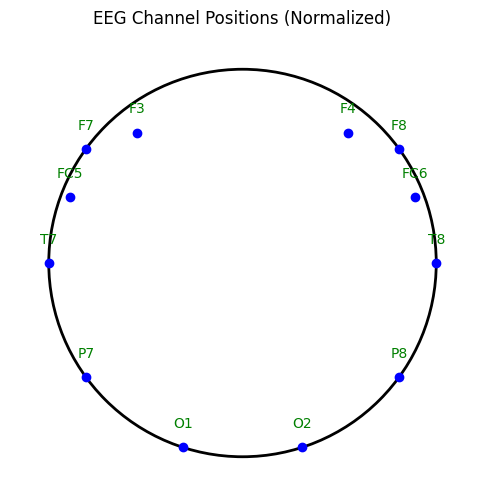

In [ ]:
# Extract the standard coordinates of the channels present in the dataset.
visualize_montage = mne.channels.make_standard_montage('standard_1020')
channel_name=['F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6','F4', 'F8']
locs_2d=[]
for channel in channel_name:
    pos=visualize_montage.get_positions()['ch_pos'][channel][:-1]
    locs_2d.append(pos)
locs_2d=np.vstack(locs_2d)
print(locs_2d)


channel_locations = {
 'F7': [-0.0768098, 0.05580558],
 'F3': [-0.05177571, 0.06393767],
 'FC5': [-0.08434934, 0.03237868],
 'T7': [-0.09494213, 0.0],
 'P7': [-0.0768098, -0.05580558],
 'O1': [-0.02933873, -0.09029533],
 'O2': [0.02933873, -0.09029533],
 'P8': [0.0768098, -0.05580558],
 'T8': [0.09494213, 0.0],
 'FC6': [0.08434934, 0.03237868],
 'F4': [0.05177571, 0.06393767],
 'F8': [0.0768098, 0.05580558]
}
# Visualize the coordinates of the channels
def normalize_positions(positions):
    max_radius = max(np.sqrt(x**2 + y**2) for x, y in positions.values())
    return {key: (x / max_radius, y / max_radius) for key, (x, y) in positions.items()}

normalized_locations = normalize_positions(channel_locations)

fig, ax = plt.subplots(figsize=(6, 6))
head_circle = plt.Circle((0, 0), 1, color='black', fill=False, lw=2)
ax.add_artist(head_circle)

for channel, (x, y) in normalized_locations.items():
    ax.plot(x, y, 'o', color='blue')
    ax.text(x, y + 0.1, channel, fontsize=10, ha='center', color='green')


ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_aspect('equal', adjustable='datalim')
ax.axis('off')
plt.title("EEG Channel Positions (Normalized)")
plt.show()

* **EXTRACT IMAGE DATA FROM EEG DATA**

In [ ]:
# The code is used to extract image features from the original digital signal data.
path = '/kaggle/input/d/anhphanmancity/eeg-data/'
output_dir="/kaggle/working/"
for i in range(0,5):
    df_list = []
    filelist=[]
    for idx in range(i*7+3,i*7+8):
        if(idx>34):
            continue
        filename=path+f"subject_{idx}.csv"
        df = pd.read_csv(filename)
        df_list.append(df)
        filelist.append(filename)
    combined_df = pd.concat(df_list, ignore_index=True)
    print(filelist)
    filename="experiment-{}v3".format(i+1)
    X_1, y_1 = make_data_pipeline(df=combined_df,image_size=28,frame_duration=1.0,overlap=0.3,locs_2d=locs_2d,output_dir=output_dir,filename=filename)
df, image_size, frame_duration, overlap, locs_2d,output_dir,filename

['/kaggle/input/d/anhphanmancity/eeg-data/subject_3.csv', '/kaggle/input/d/anhphanmancity/eeg-data/subject_4.csv', '/kaggle/input/d/anhphanmancity/eeg-data/subject_5.csv', '/kaggle/input/d/anhphanmancity/eeg-data/subject_6.csv', '/kaggle/input/d/anhphanmancity/eeg-data/subject_7.csv']
Interpolating 4266/4266nterpolating 144/4266Interpolating 308/4266Interpolating 471/4266Interpolating 627/4266Interpolating 784/4266Interpolating 950/4266Interpolating 1102/4266Interpolating 1267/4266Interpolating 1429/4266Interpolating 1591/4266Interpolating 1751/4266Interpolating 1915/4266Interpolating 2079/4266Interpolating 2235/4266Interpolating 2384/4266Interpolating 2540/4266Interpolating 2701/4266Interpolating 2846/4266Interpolating 3007/4266Interpolating 3161/4266Interpolating 3317/4266Interpolating 3475/4266Interpolating 3632/4266Interpolating 3789/4266Interpolating 3947/4266Interpolating 4108/42664266  frames generated with label  0 .

Interpolating 4266/4266nterpolating 141/4266Interpolating 30

KeyboardInterrupt: 

In [ ]:
# Load the data after the features have been extracted.
X_list,y_list=[],[]
for i in range(1, 6):
    data_path = f"/kaggle/input/brain-band-image/experiment-{i}v3.npz"
    experiment_data = np.load(data_path)

    f = experiment_data['X']
    l = experiment_data['y']

    X_list.append(f)
    y_list.append(l)

X_image = np.concatenate(X_list, axis=0)
y_image = np.concatenate(y_list, axis=0)

print(f"Data shape: {X_image.shape}, Labels shape: {y_image.shape}")


Data shape: (77090, 28, 28, 3), Labels shape: (77090,)


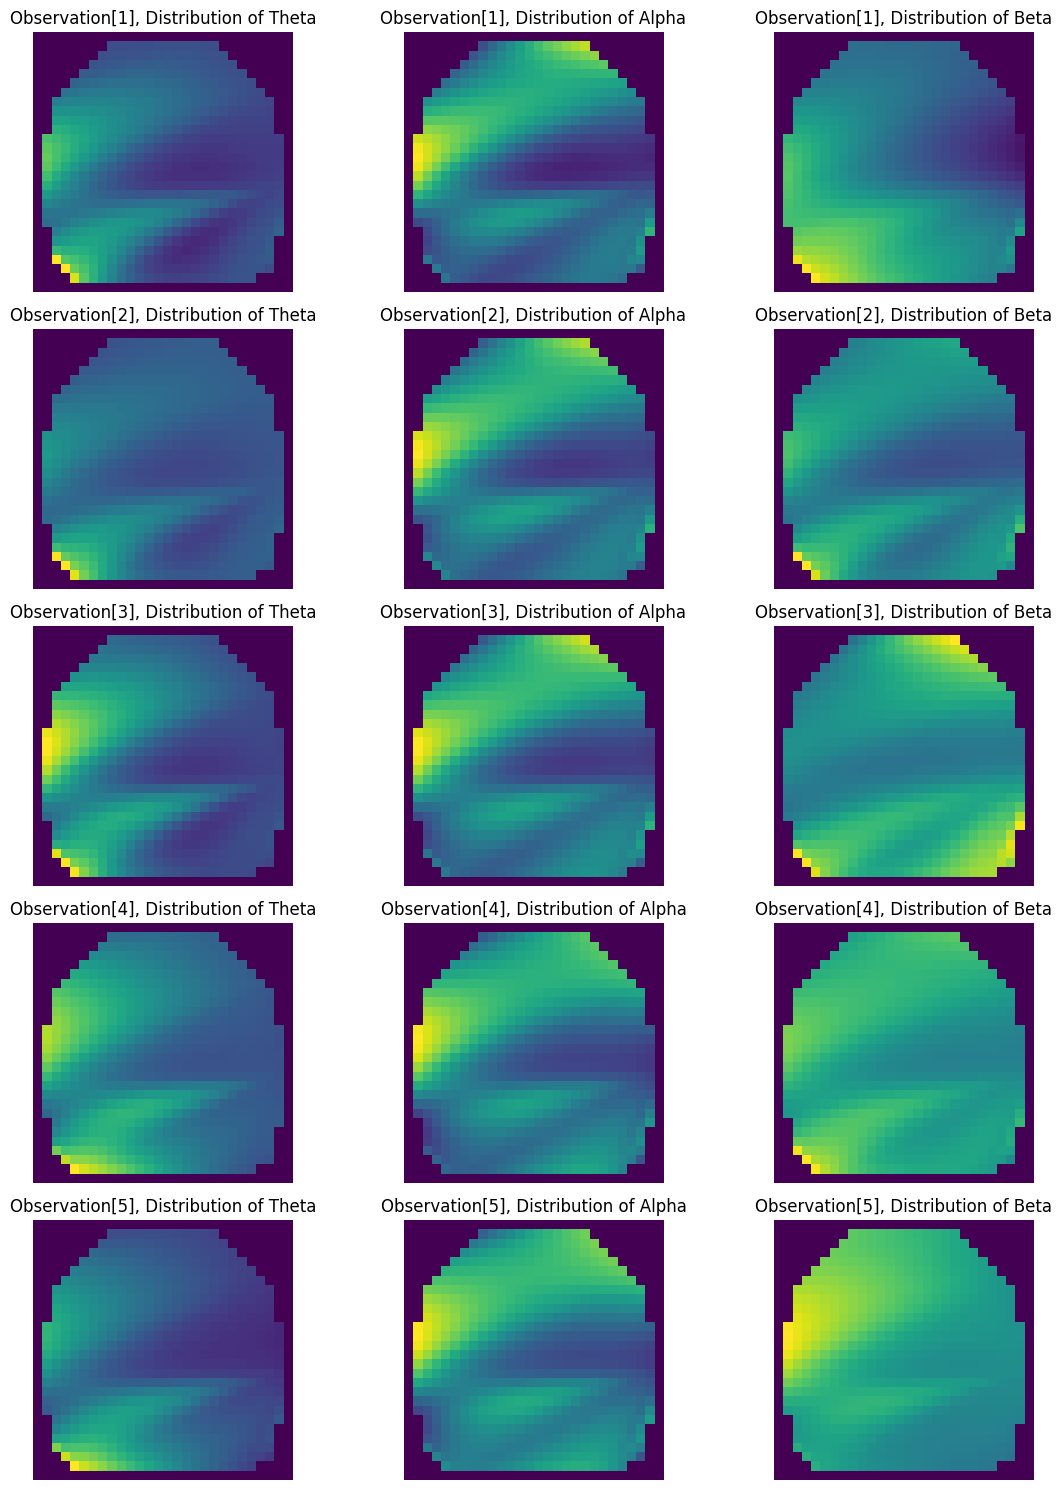

In [ ]:
idx2Categorical={
    1:"Theta",
    2:"Alpha",
    3:"Beta"
}
fig, axes = plt.subplots(5, 3, figsize=(12, 15))

for i, X in enumerate(X_list):

    mean_images = np.mean(X, axis=0)

    for j in range(3):
        axes[i, j].imshow(mean_images[:, :, j], cmap='viridis')
        axes[i, j].set_title(f"Observation[{i+1}], Distribution of {idx2Categorical[j+1]}")
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()



**Observation**: Due to the placement of the electrodes around the brain's perimeter, the color of the remaining pixels within the brain's region is approximated using interpolation methods from libraries. To assess the strength and distribution of brain waves, we will analyze whether there is significant distribution around the brain and the influence of values at the perimeter coordinates on neighboring pixels. This will help us draw conclusions about the distribution of each type of brain wave.

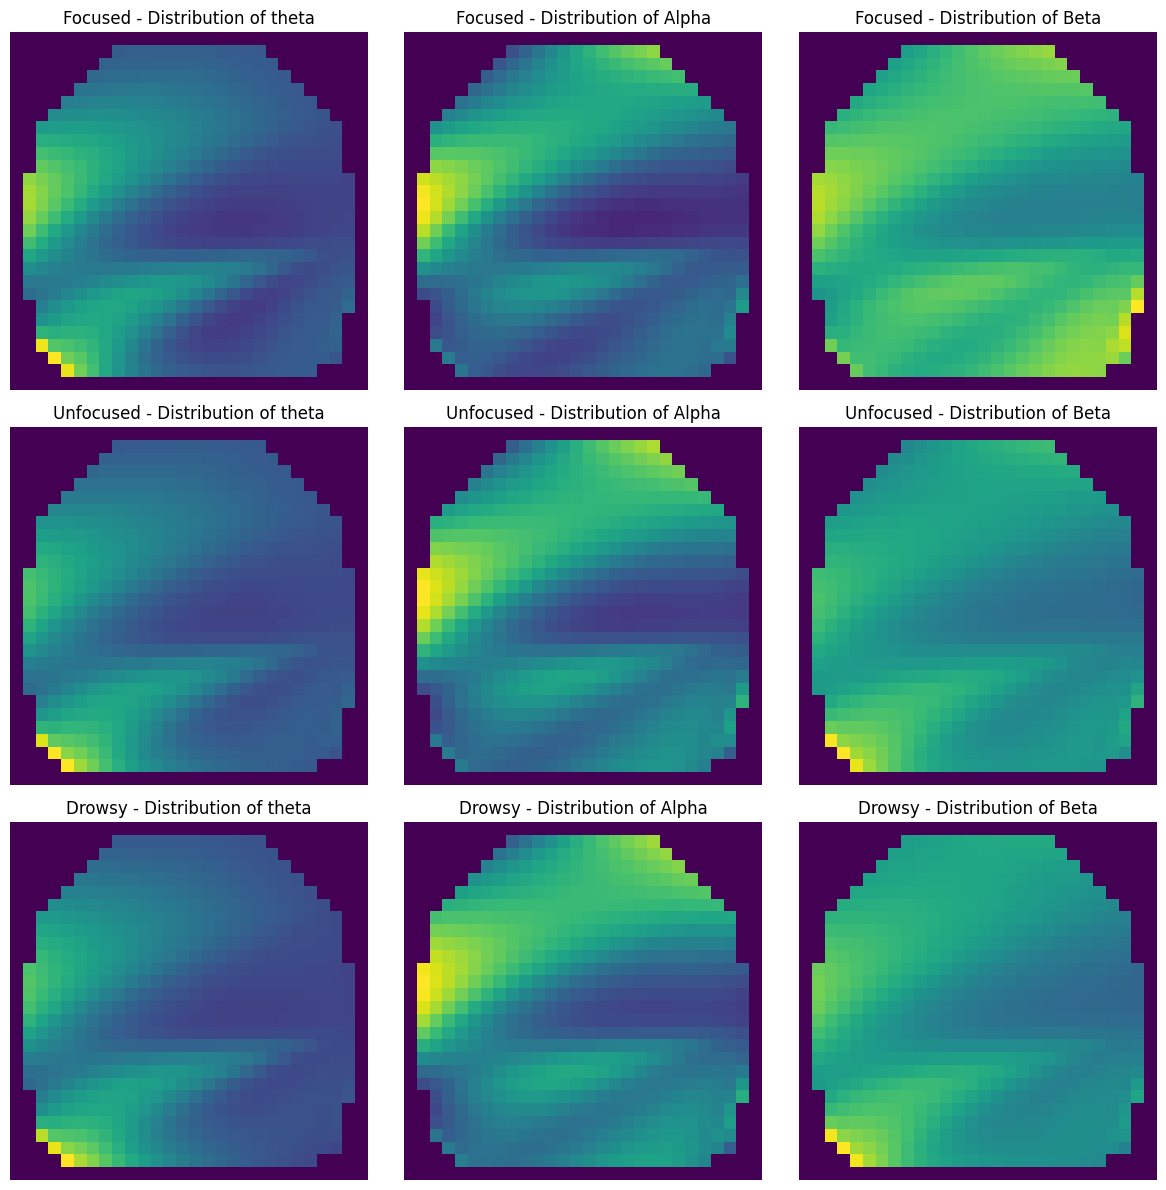

In [ ]:
idx2Categorical={
    1:"theta",
    2:"Alpha",
    3:"Beta"
}
idx_random=np.random.choice(X_image.shape[0], 20000, replace=False)
X_sample=X_image[idx_random]
y_random=y_image[idx_random]
n_sample = 20000


states = ["Focused", "Unfocused", "Drowsy"]

mean_images = np.zeros((3, 28, 28, 3))

for label in range(3):
    indices = np.where(y_image == label)[0]
    mean_images[label] = np.mean(X_image[indices], axis=0)

# Vẽ hình ảnh
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    for j in range(3):
        axes[i, j].imshow(mean_images[i, :, :, j], cmap='viridis')
        axes[i, j].set_title(f"{states[i]} - Distribution of {idx2_Categorical[j+1]}")
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()


**Observation**  
- Beta waves are quite effective in identifying whether the observer is focused or not, and they clearly differentiate between the three states.  
- Alpha and Theta waves are harder to distinguish visually, which could hinder the classification process since the differences between the three states in these two types of waves are not very clear.  
- Therefore, the model might rely on the Beta wave range to distinguish the states of focus most effectively.

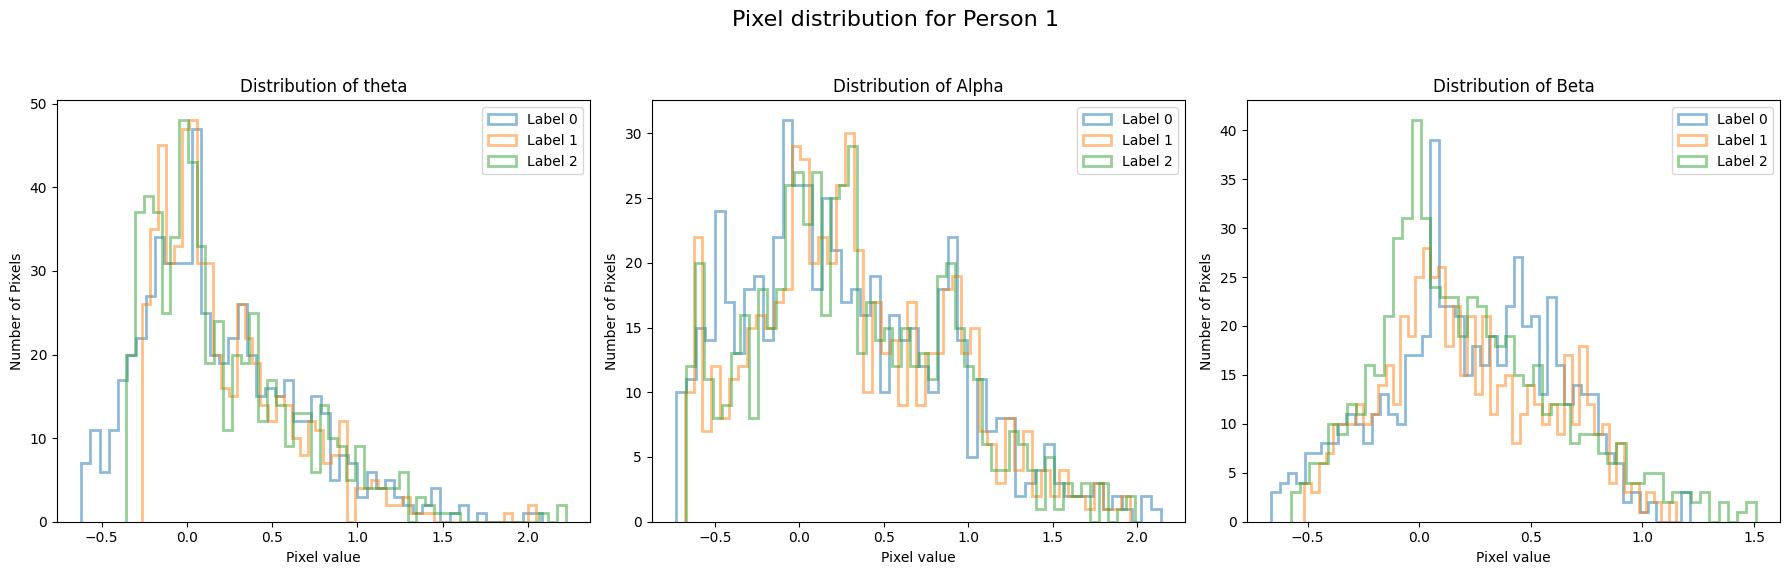

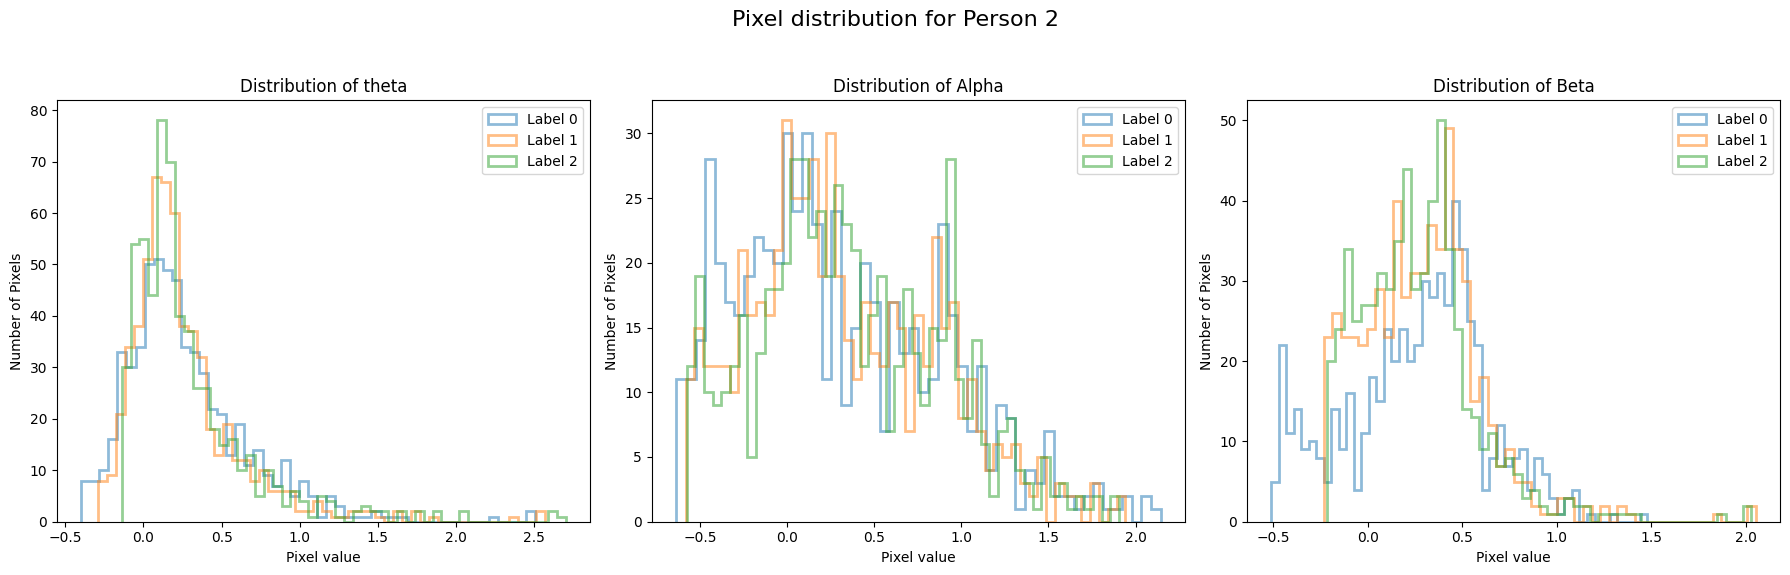

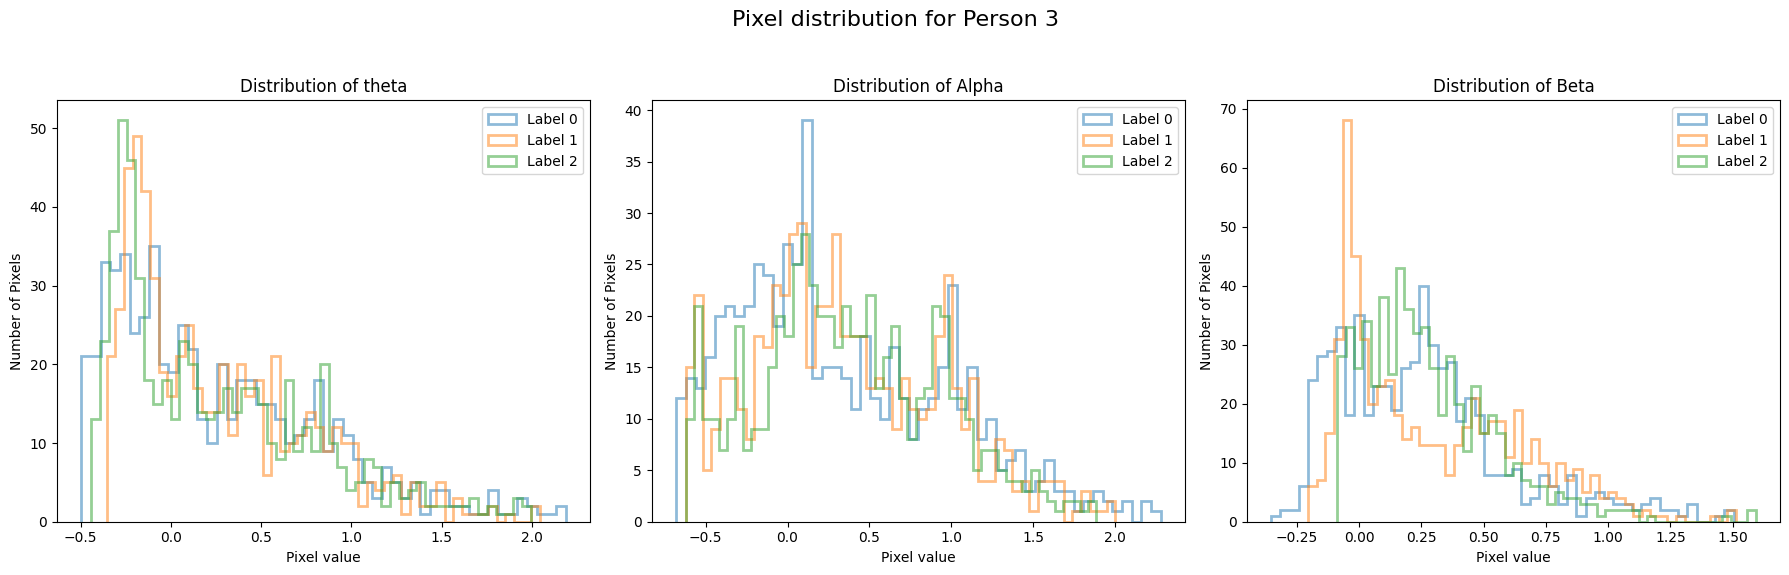

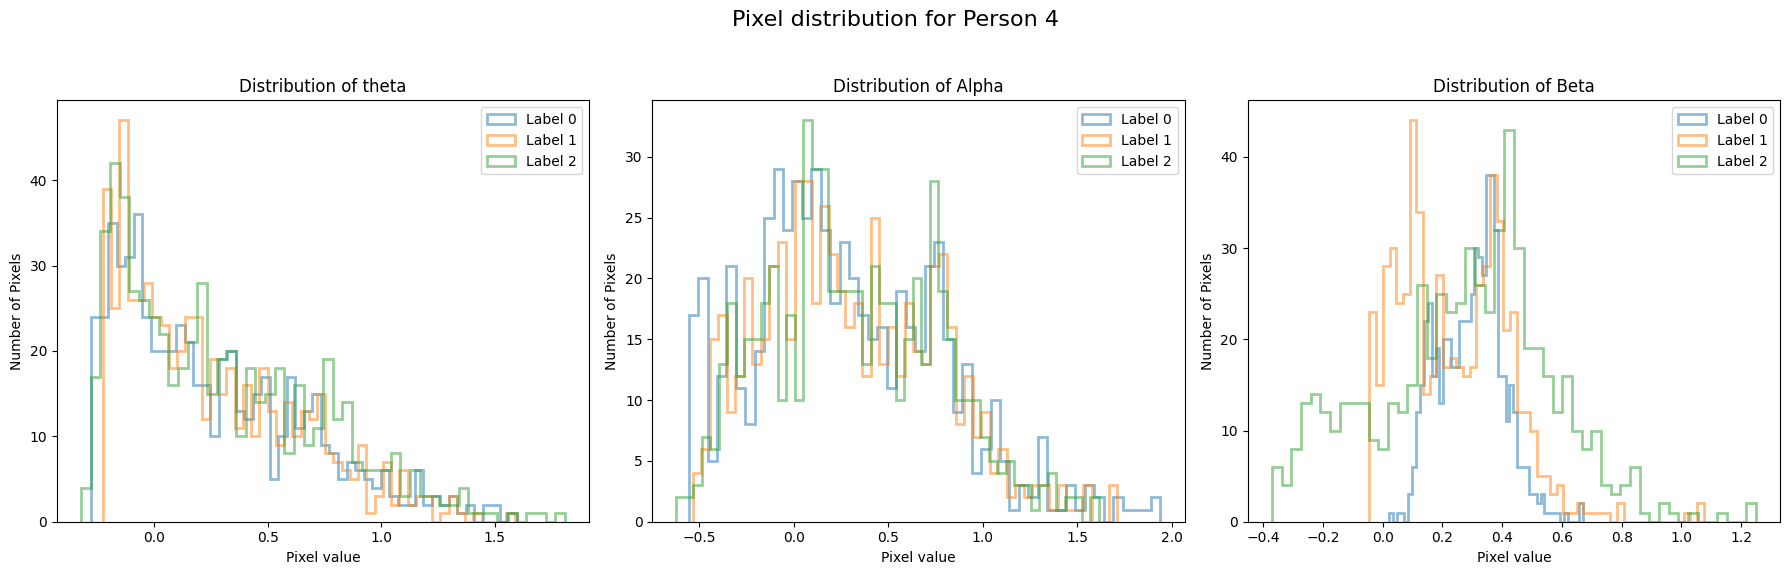

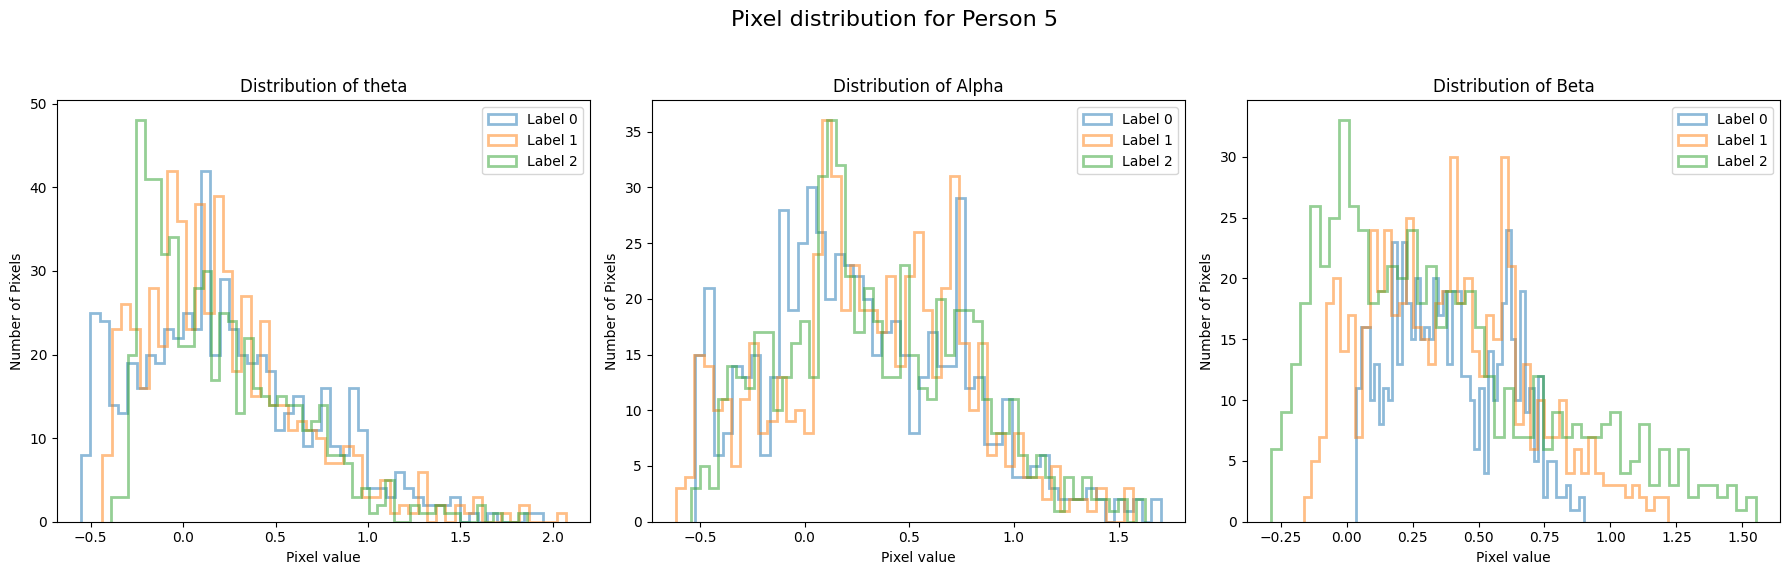

In [ ]:
n_labels = 3
for person_idx, (X, y) in enumerate(zip(X_list, y_list)):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Pixel distribution for Person {person_idx + 1}", fontsize=16)

    for channel_idx in range(3):
        ax = axes[channel_idx]


        for label in range(n_labels):
            label_indices = np.where(y == label)[0]
            channel_data = np.mean(X[label_indices, :, :, channel_idx],axis=0).flatten()

            # Tính mode và loại bỏ
            channel_mode = scs.mode(channel_data)[0]
            filtered_data = channel_data[channel_data != channel_mode]

            # Vẽ histogram
            ax.hist(filtered_data, bins=50, alpha=0.5, label=f"Label {label}", histtype='step', linewidth=2)

        ax.set_title(f"Distribution of {idx2Categorical[channel_idx+ 1]}")
        ax.set_xlabel("Pixel value")
        ax.set_ylabel("Number of Pixels")
        ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


**Observations**  
- The distribution of each label within each wave type does not differ significantly.  
- The differences are most apparent in **beta waves**, where in the *focused* state, the distribution curve is narrower, with smaller variance and a higher mean (greater than 0). This indicates that in this state, the images appear "brighter" and are more distinguishable from other states.  
- For **alpha waves**, it can be observed that in the *unfocused* and *drowsy* states, the distribution curves exhibit smaller variances compared to the *focused* state. In terms of imagery, the *focused* state would appear "darker" than the other two states. However, there is no significant difference between the *unfocused* and *drowsy* states in this wave type.  
- Regarding **theta waves**, the *drowsy* and *unfocused* states differ quite clearly from the *focused* state. Specifically, the *drowsy* state shows a more prominent distribution curve compared to the other two states. Consequently, in terms of imagery, the color channel for theta waves in the *drowsy* state would appear "brighter" compared to the other states.  

* **Data preparation steps for the training process:**
    - Adjust the number of samples to avoid class imbalance.
    - Normalize the data.
    - Split the dataset into training, testing, and validation sets.
    - Create dataloaders for each subset.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def create_image_loader(X,y,sampling=False):
    if sampling is not False:
        X_resampled,y_resampled=balance_data(X,y)
    else:
        X_resampled,y_resampled=X,y
    H,W,C=28,28,3
    batch_size=128
    X_reshaped=X_resampled.reshape(-1,C)
    scaler = StandardScaler()
    X_reshaped=scaler.fit_transform(X_reshaped)
    X_reshaped=scaler.transform(X_reshaped)
    X_normalized=X_reshaped.reshape(X_resampled.shape)

    x_train, x_test, y_train, y_test = train_test_split(X_normalized, y_resampled, test_size=0.30,shuffle=True)
    x_train,x_valid,y_train,y_valid = train_test_split(x_train, y_train, test_size=0.20,shuffle=True)
    # input image dimensions
    img_rows, img_cols = 28, 28

    print('x_train shape:', x_train.shape)
    print(x_train.shape[0], 'train samples')
    print(x_test.shape[0], 'test samples')
    print(x_valid.shape[0],'valid samples')

    input_shape = (img_rows, img_cols, 3)
    # Preprocess the input data (normalize to range [0, 1])
    x_train = x_train.astype('float32')
    x_test = x_test.astype('float32')
    x_valid = x_valid.astype('float32')

    # Convert to torch tensors
    x_train_tensor = torch.tensor(x_train).permute(0, 3,1, 2) .to(device) # Convert to (batch, channels, height, width)
    x_test_tensor = torch.tensor(x_test).permute(0, 3,1, 2).to(device)
    x_valid_tensor=torch.tensor(x_valid).permute(0,3,1, 2).to(device)

    y_train_tensor = torch.tensor(y_train).to(device)
    y_test_tensor = torch.tensor(y_test).to(device)
    y_valid_tensor = torch.tensor(y_valid).to(device)

    # Create DataLoader for training and testing datasets
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor,)
    test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
    valid_dataset=TensorDataset(x_valid_tensor, y_valid_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    valid_loader=DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

    return train_loader,test_loader,valid_loader

* **Create the necessary layers to build a CNN model based on the ResNet architecture concept**

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.batchnorm1 = nn.BatchNorm2d(out_channels)
        self.batchnorm2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.LeakyReLU()

        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None

    def forward(self, x):
        identity = x
        out = self.relu(self.batchnorm1(self.conv1(x)))
        out = self.batchnorm2(self.conv2(out))

        if self.shortcut is not None:
            identity = self.shortcut(identity)

        out += identity
        out = self.relu(out)
        return out
class CNNModel(nn.Module):
    def __init__(self, input_shape, num_classes):
        super(CNNModel, self).__init__()

        # Define the layers
        self.res_block1=ResidualBlock(input_shape[2],out_channels=64)
        self.res_block2=ResidualBlock(in_channels=64,out_channels=64)
        self.res_block3=ResidualBlock(in_channels=64,out_channels=128)
        self.res_block4=ResidualBlock(in_channels=128,out_channels=256)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256 * (input_shape[0] // 4 ) * (input_shape[1] // 4 ), 784)
        self.batchnorm1 = nn.BatchNorm1d(784)
        self.dropout = nn.Dropout(p=0.1)
        self.fc2 = nn.Linear(784, 32)
        self.activation = nn.LeakyReLU()
        self.batchnorm2=nn.BatchNorm1d(32)
        self.fc3=nn.Linear(32,num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.res_block1(x)
        x=self.res_block2(x)
        x = self.pool(x)
        x=self.res_block3(x)
        x=self.res_block4(x)
        x=self.pool(x)
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.batchnorm1(x)
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        x=self.batchnorm2(x)
        x=self.dropout(x)
        x=self.fc3(x)
        score=self.softmax(x)
        return x,score




* **Training and evaluation procces**

x_train shape: (43170, 28, 28, 3)
43170 train samples
23127 test samples
10793 valid samples
Epoch [0/5], Loss: 0.6905, Accuracy: 71.43% , AUC: 0.8851,f1:0.71
              precision    recall  f1-score   support

         0.0       0.81      0.97      0.88      2853
         1.0       0.75      0.83      0.78      2937
         2.0       0.96      0.79      0.86      5003

    accuracy                           0.85     10793
   macro avg       0.84      0.86      0.84     10793
weighted avg       0.86      0.85      0.85     10793

AUC: 0.9625
F1 Score: 0.8438
Test Accuracy: 84.68%
Epoch [1/5], Loss: 0.3914, Accuracy: 87.39% , AUC: 0.9755,f1:0.87
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94      2853
         1.0       0.87      0.89      0.88      2937
         2.0       0.96      0.92      0.94      5003

    accuracy                           0.92     10793
   macro avg       0.92      0.92      0.92     10793
weighted avg     

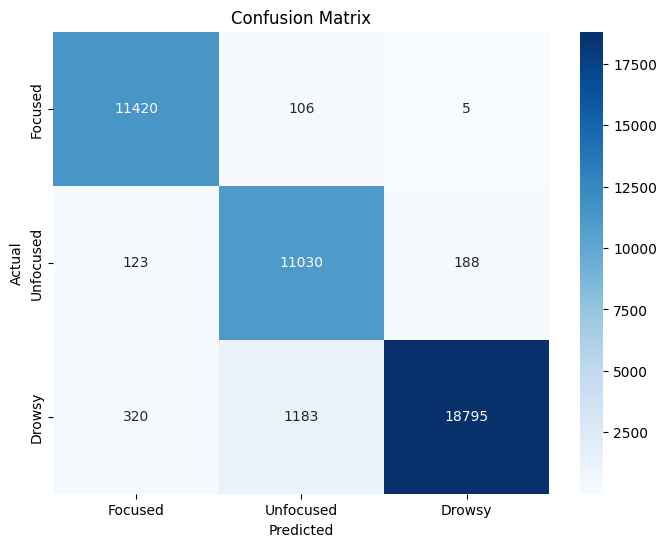

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 128
num_classes = 3
epochs = 5
learning_rate = 1e-5
# Create class weights for the loss function to prevent model bias towards the class with more samples.
class_counts=count_classes(y)
class_weights = 1.0 / class_counts
class_weights = torch.tensor(class_weights / class_weights.min(), dtype=torch.float32).to(device)

model = CNNModel(input_shape=(28, 28, 3),num_classes=3).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate,weight_decay=1e-4)
criterion=nn.CrossEntropyLoss(weight=class_weights)
train_loader,test_loader,valid_loader=create_image_loader(X=X_image,y=y_image,sampling=False)
train_metrics,valid_metrics=train(model,train_loader=train_loader,valid_loader=valid_loader,criterion=criterion,optimizer=optimizer,epochs=epochs)

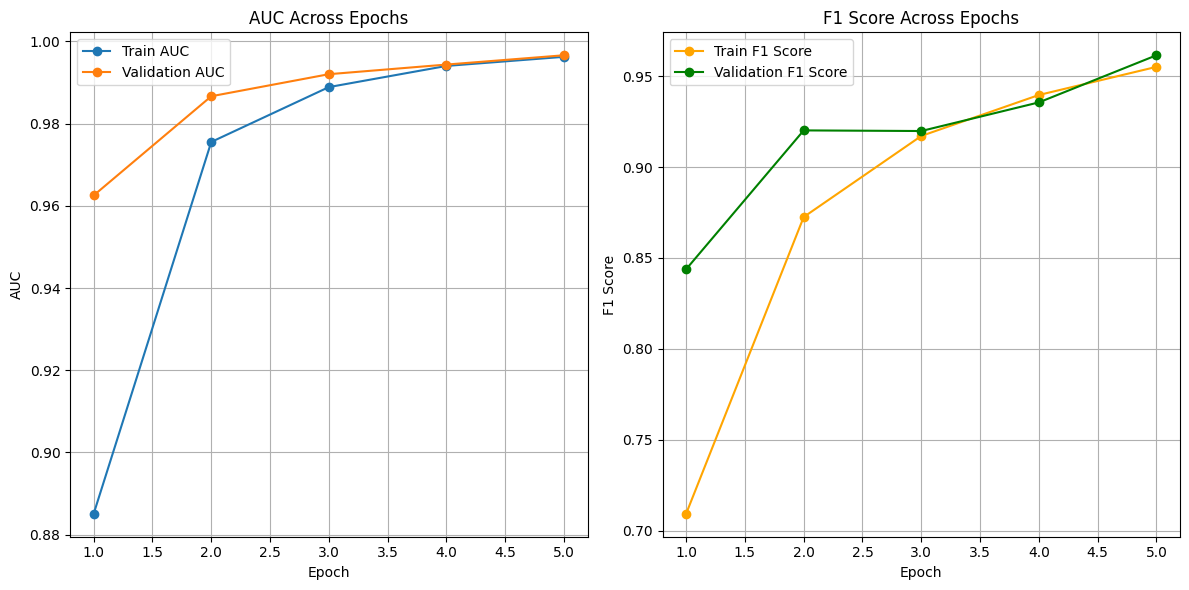

In [ ]:
def plot_metrics(train_auc, valid_auc, train_f1, valid_f1, epochs):
    """
    Plot AUC and F1 score for training and validation sets.

    Parameters:
    - train_auc: List or array of AUC values for the training set.
    - valid_auc: List or array of AUC values for the validation set.
    - train_f1: List or array of F1 scores for the training set.
    - valid_f1: List or array of F1 scores for the validation set.
    - epochs: Number of epochs (used for x-axis).

    Returns:
    - None
    """
    x = range(1, epochs + 1)

    # Plot AUC
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)  # Create the first subplot
    plt.plot(x, train_auc, label='Train AUC', marker='o')
    plt.plot(x, valid_auc, label='Validation AUC', marker='o')
    plt.title('AUC Across Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid()

    # Plot F1 Score
    plt.subplot(1, 2, 2)  # Create the second subplot
    plt.plot(x, train_f1, label='Train F1 Score', marker='o', color='orange')
    plt.plot(x, valid_f1, label='Validation F1 Score', marker='o', color='green')
    plt.title('F1 Score Across Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_metrics(train_auc=train_metrics[0], valid_auc=valid_metrics[0], train_f1=train_metrics[1], valid_f1=valid_metrics[1], epochs=5)

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98      6092
         1.0       0.93      0.97      0.95      6136
         2.0       0.99      0.95      0.97     10899

    accuracy                           0.96     23127
   macro avg       0.96      0.97      0.96     23127
weighted avg       0.96      0.96      0.96     23127

AUC: 0.9965
F1 Score: 0.9634
Test Accuracy: 96.39%
Confusion Matrix:
[[ 6054    36     2]
 [   84  5923   129]
 [  170   413 10316]]


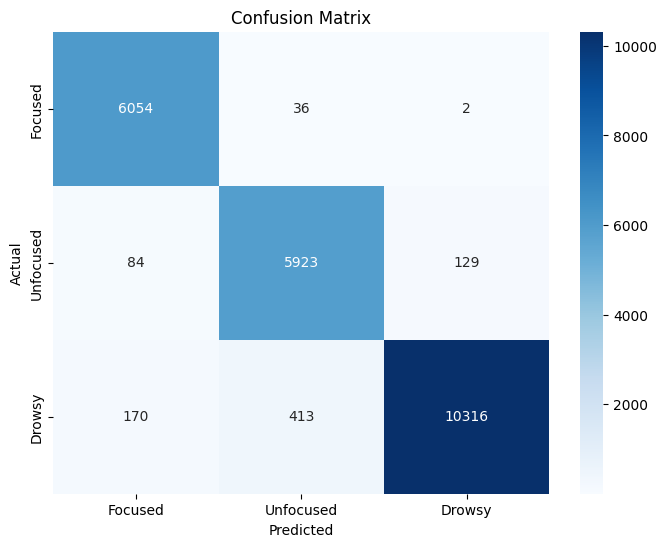

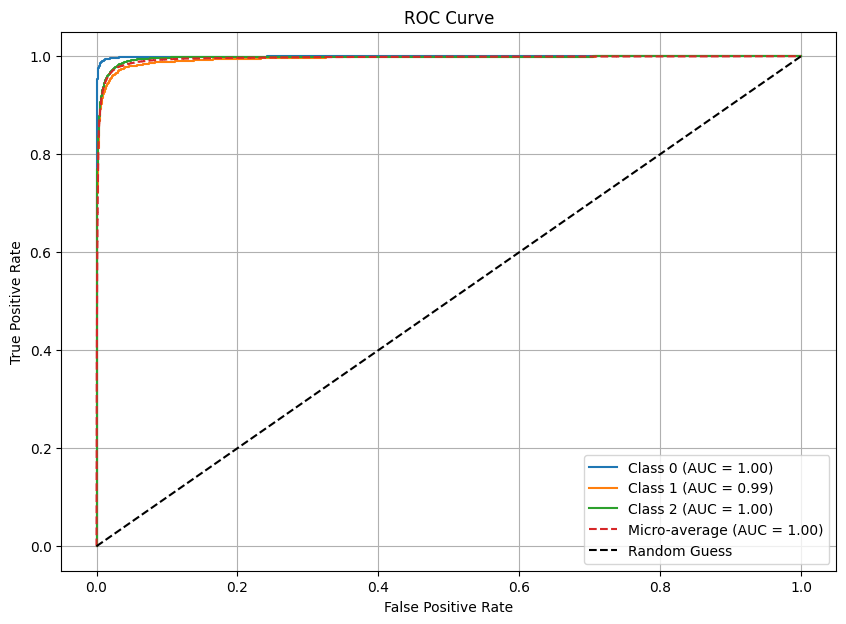

In [ ]:
def plot_ROC_curves(model, test_loader):
    _,fpr, tpr, roc_auc_per_class = evaluate(model, test_loader,print_matrix=True)

    plt.figure(figsize=(10, 7))

    # Vẽ ROC curve cho từng lớp
    for i in range(3):  # Lặp qua 3 lớp (0, 1, 2)
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc_per_class[i]:.2f})')

    # Vẽ ROC curve cho micro-average
    plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average (AUC = {roc_auc_per_class["micro"]:.2f})', linestyle='--')

    # Vẽ đường chéo cho random guessing
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

    # Các thông số cho đồ thị
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()
plot_ROC_curves(model,test_loader=test_loader)

**Observations**:  
- The area under the curve (AUC) for all classes (Class 0, Class 1, and Class 2) is close to 1.00. This indicates that the model can perfectly distinguish between the classes. The micro-average AUC score is also 1.00, reinforcing this conclusion. This can be explained by the differences in the distribution of wave bands and states, as analyzed earlier. The CNN model, which incorporates part of the ResNet architecture, is capable of learning these features effectively and making highly accurate predictions.  
- The F1-score of 0.96 is very high, and from the confusion matrix, it is evident that the model predicts the classes clearly with only minimal error
- The model shows no signs of overfitting because the F1_score and accuracy indexes still increase on both validation and training sets.  

**Using oversampling to address imbalanced data and retrain the model**

x_train shape: (60816, 28, 28, 3)
60816 train samples
32580 test samples
15204 valid samples
Epoch [0/5], Loss: 0.5598, Accuracy: 76.24% , AUC: 0.9161,f1:0.76
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94      5021
         1.0       0.87      0.89      0.88      5176
         2.0       0.94      0.84      0.89      5007

    accuracy                           0.90     15204
   macro avg       0.91      0.90      0.90     15204
weighted avg       0.91      0.90      0.90     15204

AUC: 0.9822
F1 Score: 0.9038
Test Accuracy: 90.44%
Epoch [1/5], Loss: 0.2758, Accuracy: 91.48% , AUC: 0.9857,f1:0.91
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      5021
         1.0       0.86      0.98      0.92      5176
         2.0       0.98      0.85      0.91      5007

    accuracy                           0.94     15204
   macro avg       0.94      0.93      0.94     15204
weighted avg     

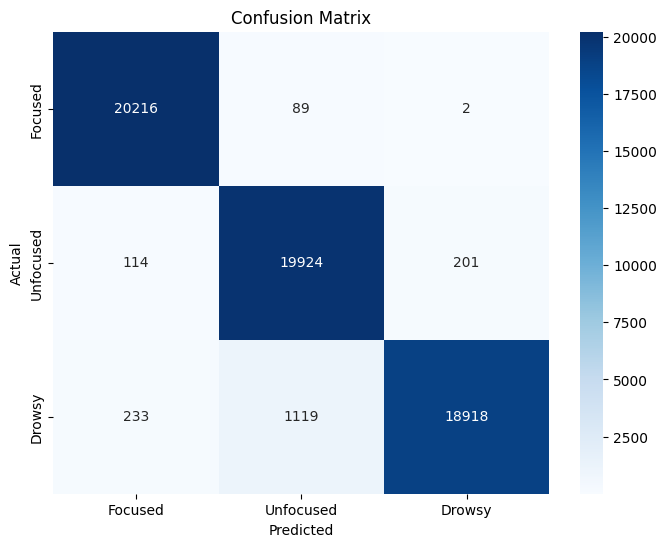

In [ ]:
train_loader,test_loader,valid_loader=create_image_loader(X=X_image,y=y_image,sampling=True)
train_metrics,valid_metrics=train(model,train_loader=train_loader,valid_loader=valid_loader,criterion=criterion,optimizer=optimizer,epochs=epochs)

**Re-predict the model on the old data set to ensure correctness**

x_train shape: (43170, 28, 28, 3)
43170 train samples
23127 test samples
10793 valid samples
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      6090
         1.0       0.88      1.00      0.94      6094
         2.0       1.00      0.93      0.96     10943

    accuracy                           0.96     23127
   macro avg       0.96      0.97      0.96     23127
weighted avg       0.97      0.96      0.96     23127

AUC: 0.9984
F1 Score: 0.9626
Test Accuracy: 96.19%
Confusion Matrix:
[[ 6041    49     0]
 [   11  6065    18]
 [   52   752 10139]]


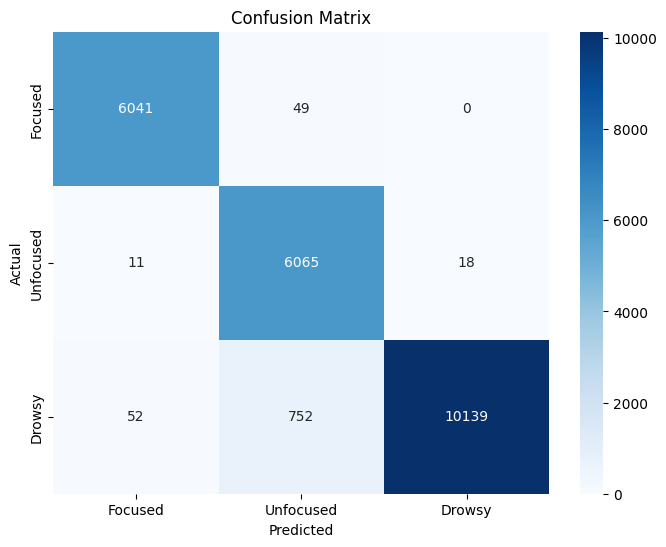

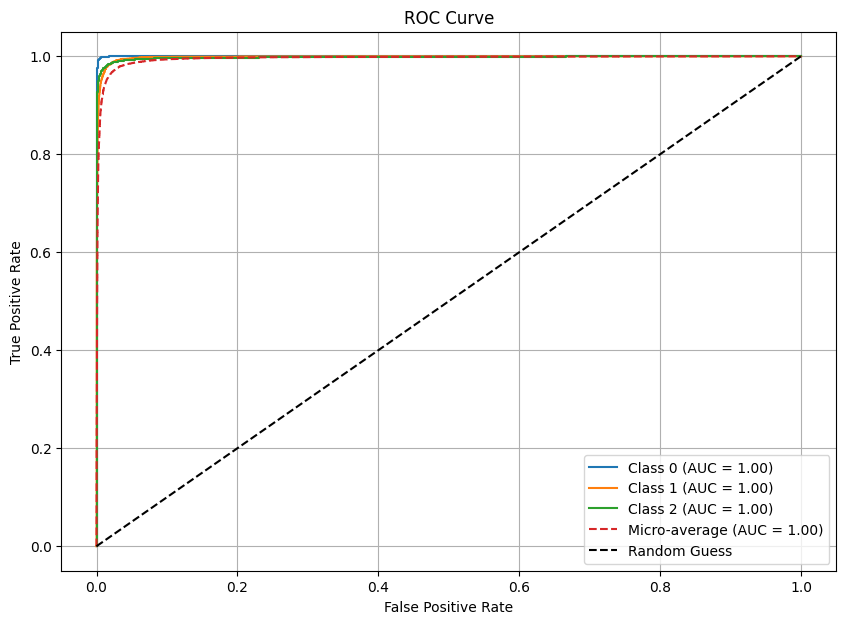

In [ ]:
_,test_loader,_=create_image_loader(X=X_image,y=y_image,sampling=False)
plot_ROC_curves(model,test_loader=test_loader)

**Observations**:  
- After applying sampling techniques to the training dataset, we observe that the model's performance does not change significantly.  
- This suggests that the model has learned the dataset very well and does not show signs of overfitting, as the metrics on both the training and validation sets consistently improve without any decline.  

### CONVOLUTION 1D FOR EEG DATA

* Generate training data samples, where each sample consists of 128 samples from the original dataset and the samples overlap by a ratio of 0.3.

In [ ]:
path = '/kaggle/input/d/anhphanmancity/eeg-data/' # Path to the original dataset.
output_dir="/kaggle/working/" # Path to the output data
state_encode = {
        '1': 0,
        '2': 1,
        '0': 2
    }

for i in range(0,5):
    df_list = []
    filelist=[]
    for idx in range(i*7+3,i*7+8):
        if(idx>34):
            continue
        filename=path+f"subject_{idx}.csv"
        df = pd.read_csv(filename)
        df_list.append(df)
        filelist.append(filename)
    combined_df = pd.concat(df_list, ignore_index=True).drop(columns=["AF3","AF4"])
    print(filelist)
    steps=make_steps(len(combined_df),1.0,0.3)

    epoch_array=[]
    labels=[]

    for start,end in steps:
        snippet=np.array(combined_df.iloc[int(start):int(end),:-1])
        labels.append(state_encode[str(combined_df["state"].iloc[int(start)])])
        epoch_array.append(snippet)
    filename=f"experiment-{i+1}-signal"
    np.savez(output_dir+filename+".npz",X=epoch_array,y=labels)
    print("successful in subject {}".format(i+1))

['/kaggle/input/d/anhphanmancity/eeg-data/subject_3.csv', '/kaggle/input/d/anhphanmancity/eeg-data/subject_4.csv', '/kaggle/input/d/anhphanmancity/eeg-data/subject_5.csv', '/kaggle/input/d/anhphanmancity/eeg-data/subject_6.csv', '/kaggle/input/d/anhphanmancity/eeg-data/subject_7.csv']


KeyboardInterrupt: 

In [ ]:
# Load the data from file .npz
X_signal, y_signal = [], []
for i in range(1, 6):
    file_path = f"/kaggle/input/signal-subjectv2/experiment-{i}-signal.npz"
    data = np.load(file_path)
    f, l = data['X'], data['y']

    X_signal.append(f)
    y_signal.append(l)

X_signal = np.concatenate(X_signal, axis=0)
y_signal = np.concatenate(y_signal, axis=0)


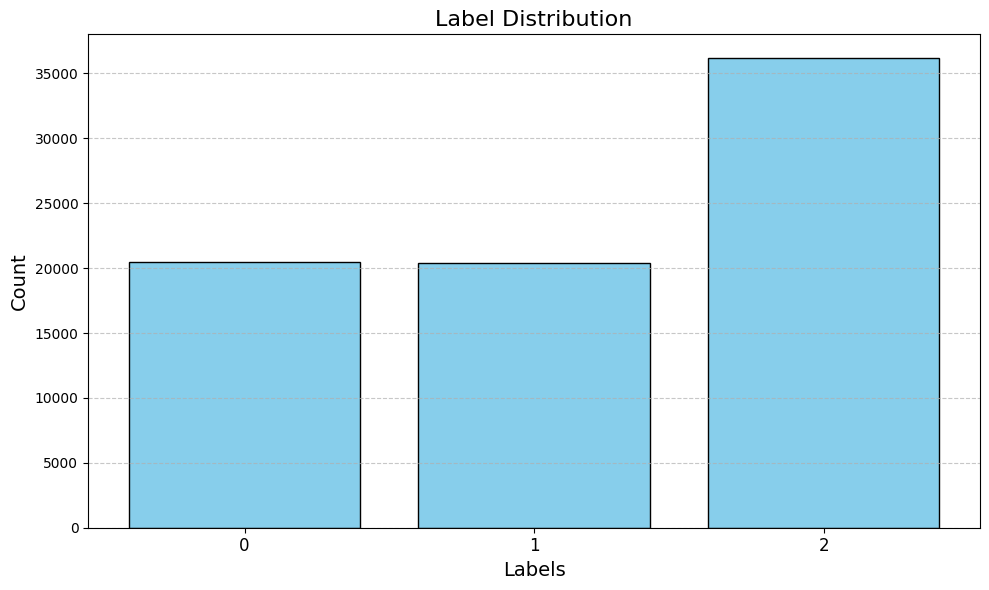

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_label_distribution(subject_y):
    """
    Plots the label distribution as a bar chart.

    Parameters:
    subject_y (np.array): The array containing the labels (e.g., 'state').
    """
    # Count the occurrences of each label
    unique, label_counts = np.unique(subject_y, return_counts=True)

    # Plot the bar graph
    plt.figure(figsize=(10, 6))
    plt.bar(unique, label_counts, color='skyblue', edgecolor='black')

    # Add titles and labels
    plt.title('Label Distribution', fontsize=16)
    plt.xlabel('Labels', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.xticks(unique, rotation=0, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Show the plot
    plt.tight_layout()
    plt.show()

plot_label_distribution(subject_y=y_signal)


* Comment: Although the data is imbalanced, it is not too severe, but it will affect the model training process

* Data preparation steps for the training process:
    - Adjust the number of samples to avoid class imbalance.
    - Normalize the data.
    - Split the dataset into training, testing, and validation sets.
    - Create dataloaders for each subset.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def create_signal_loader(X,y,sampling=False):
    if sampling:
        X_resampled,y_resampled=balance_data(X,y)
    else:
        X_resampled,y_resampled=X,y
    H = 128
    C = 12
    samples=X_resampled.shape[0]
    scaler = StandardScaler()
    X_reshaped = X_resampled.reshape(-1, C)
    X_normalized = scaler.fit_transform(X_reshaped)
    X_normalized = X_normalized.reshape(samples, H, C)
    X_normalized = np.transpose(X_normalized, (0, 2, 1))

    x_train, x_test, y_train, y_test = train_test_split(X_normalized, y_resampled, test_size=0.20,shuffle=True)
    x_train,x_valid,y_train,y_valid = train_test_split(x_train, y_train, test_size=0.20,shuffle=True)

    print('x_train shape:', x_train.shape)
    print(x_train.shape[0], 'train samples')
    print(x_test.shape[0], 'test samples')
    print(x_valid.shape[0],'valid samples')

    x_train = x_train.astype('float32')
    x_test = x_test.astype('float32')
    x_valid = x_valid.astype('float32')

    x_train_tensor = torch.tensor(x_train).to(device)
    x_test_tensor = torch.tensor(x_test).to(device)
    x_valid_tensor=torch.tensor(x_valid).to(device)

    y_train_tensor = torch.tensor(y_train).to(device)
    y_test_tensor = torch.tensor(y_test).to(device)
    y_valid_tensor = torch.tensor(y_valid).to(device)

    # Create DataLoader for training and testing datasets
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor,)
    test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
    valid_dataset=TensorDataset(x_valid_tensor, y_valid_tensor)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    valid_loader=DataLoader(valid_dataset, batch_size=64, shuffle=False)

    return train_loader,test_loader,valid_loader



* **Functions for the training and evaluation process**

In [ ]:
def train(model,train_loader, valid_loader,criterion,optimizer,epochs,print_matrix=True):
    valid_auc=[]
    valid_f1=[]
    train_auc=[]
    train_f1=[]
    model.train()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        all_labels = []
        all_probs = []


        for inputs, labels in train_loader:
            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs,score = model(inputs)

            labels = labels.long()
            # Compute the loss
            loss = criterion(outputs, labels).to(device)
            #loss=focal_loss(outputs,labels).to(device)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(score, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.append(labels.cpu().numpy())
            all_probs.append(torch.softmax(outputs, dim=1).cpu().detach().numpy())


        all_labels = np.concatenate(all_labels, axis=0)
        all_probs = np.concatenate(all_probs, axis=0)

        if all_labels.ndim == 1:
            all_labels = np.eye(num_classes)[all_labels]
        roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        if all_labels.ndim > 1:
            all_labels = np.argmax(all_labels, axis=1)
        predicted_classes = np.argmax(all_probs, axis=1)
        f1 = f1_score(all_labels, predicted_classes, average='macro')
        print(f"Epoch [{epoch}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100*correct/total:.2f}% , AUC: {roc_auc:.4f},f1:{f1:.2f}")
        metrics,_,_,_=evaluate(model,valid_loader)
        valid_auc.append(metrics[0])
        valid_f1.append(metrics[1])
        train_auc.append(roc_auc)
        train_f1.append(f1)


    if print_matrix is not False:
        cm = confusion_matrix(all_labels, predicted_classes)
        print("Confusion Matrix:")
        print(cm)
        plot_confusion_matrix(cm, labels=["Focused", "Unfocused", "Drowsy"])
    return [train_auc,train_f1],[valid_auc,valid_f1]




def evaluate(model, dataloader,print_matrix=False):
    model.eval()
    correct = 0
    total = 0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            outputs, score = model(inputs)
            _, predicted = torch.max(score, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.append(labels.cpu().numpy())
            all_probs.append(torch.softmax(outputs, dim=1).cpu().detach().numpy())

    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

    roc_auc = roc_auc_score(all_labels_bin, all_probs, multi_class='ovr', average='macro')

    predicted_classes = np.argmax(all_probs, axis=1)
    f1 = f1_score(all_labels, predicted_classes, average='macro')

    print(classification_report(all_labels, predicted_classes))

    print(f"AUC: {roc_auc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Test Accuracy: {100 * correct / total:.2f}%")

    if print_matrix is not False:
        cm = confusion_matrix(all_labels, predicted_classes)
        print("Confusion Matrix:")
        print(cm)
        plot_confusion_matrix(cm, labels=["Focused", "Unfocused", "Drowsy"])


    fpr, tpr, roc_auc_per_class = {}, {}, {}


    for i in range(3):  # 3 lớp (0, 1, 2)
        fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc_per_class[i] = auc(fpr[i], tpr[i])


    fpr["micro"], tpr["micro"], _ = roc_curve(all_labels_bin.ravel(), all_probs.ravel())
    roc_auc_per_class["micro"] = auc(fpr["micro"], tpr["micro"])

    return [roc_auc, f1], fpr, tpr, roc_auc_per_class
def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

* Create a CNN model structure with Conv1D layers, Pooling layers, and Fully Connected layers.

In [ ]:
class EEGNet(nn.Module):
    def __init__(self, inp_shape,classes):
        super(HopefullNet, self).__init__()
        self.inp_shape = inp_shape

        self.kernel_size_0 = 35
        self.kernel_size_1 = 1
        self.drop_rate = 0.5

        self.conv1 = nn.Conv1d(in_channels=inp_shape[1],
                               out_channels=32,
                               kernel_size=self.kernel_size_0,
                               padding='same')
        self.batch_n_1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(in_channels=32,
                               out_channels=32,
                               kernel_size=self.kernel_size_0)
        self.batch_n_2 = nn.BatchNorm1d(32)
        self.avg_pool1 = nn.AvgPool1d(kernel_size=2)
        self.spatial_drop_1 = nn.Dropout(self.drop_rate)
        self.conv3 = nn.Conv1d(in_channels=32,
                               out_channels=64,
                               kernel_size=self.kernel_size_1)

        self.conv4 = nn.Conv1d(in_channels=64,
                               out_channels=64,
                               kernel_size=self.kernel_size_1)
        self.avg_pool2 = nn.AvgPool1d(kernel_size=2)
        self.spatial_drop_2 = nn.Dropout(self.drop_rate)
        self.flat = nn.Flatten()
        self.dense1 = nn.Linear(64 * (((inp_shape[0] - 35 + 1) // 2)), 128)
        self.dropout1 = nn.Dropout(self.drop_rate)
        self.dense2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(self.drop_rate)
        self.dense3 = nn.Linear(64, 32)
        self.dropout3 = nn.Dropout(self.drop_rate)
        self.out = nn.Linear(32, classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.batch_n_1(x)
        x = F.relu(self.conv2(x))
        x = self.batch_n_2(x)
        x = self.spatial_drop_1(x)
        x = self.avg_pool1(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.spatial_drop_2(x)
        x = self.flat(x)
        x = F.relu(self.dense1(x))
        x = self.dropout1(x)
        x = F.relu(self.dense2(x))
        x = self.dropout2(x)
        x = F.relu(self.dense3(x))
        x = self.dropout3(x)
        x=self.out(x)
        score=self.softmax(x)

        return x,score


* **Initialize the model and start the training and evaluation process**

x_train shape: (37007, 12, 128)
37007 train samples
30840 test samples
9252 valid samples
Epoch [0/20], Loss: 1.0681, Accuracy: 42.08% , AUC: 0.5892,f1:0.37
              precision    recall  f1-score   support

           0       0.44      0.78      0.56      2481
           1       0.36      0.05      0.09      2511
           2       0.63      0.66      0.65      4260

    accuracy                           0.53      9252
   macro avg       0.48      0.50      0.43      9252
weighted avg       0.50      0.53      0.47      9252

AUC: 0.6984
F1 Score: 0.4340
Test Accuracy: 52.82%
Epoch [1/20], Loss: 0.9787, Accuracy: 52.67% , AUC: 0.6922,f1:0.50
              precision    recall  f1-score   support

           0       0.57      0.61      0.59      2481
           1       0.36      0.47      0.41      2511
           2       0.71      0.54      0.61      4260

    accuracy                           0.54      9252
   macro avg       0.54      0.54      0.54      9252
weighted avg      

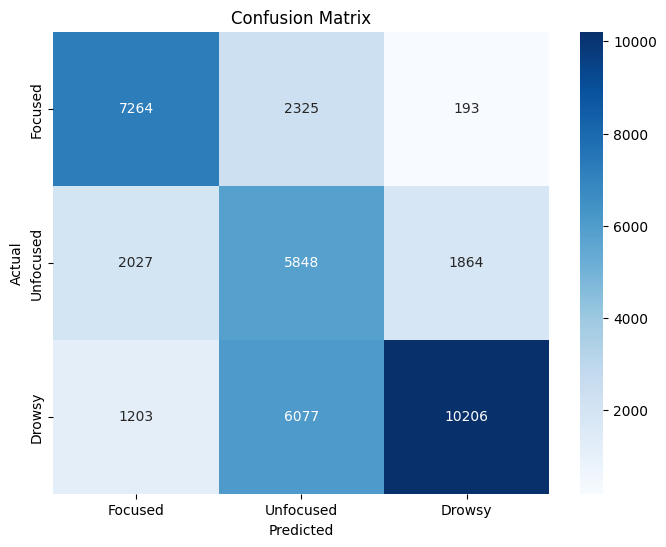

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_shape=(128,12)
num_classes = 3
epochs = 20
learning_rate = 1e-3
# Create class weights for the loss function to prevent model bias towards the class with more samples.
class_counts=count_classes(y)
class_weights = 1.0 / class_counts
class_weights = torch.tensor(class_weights / class_weights.min(), dtype=torch.float32).to(device)
# initialize dataloader
train_loader,test_loader,valid_loader=create_signal_loader(X=X_signal,y=y_signal)

model2=EEGNet(inp_shape=input_shape,classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model2.parameters(), lr=learning_rate,weight_decay=1e-5)

train_metrics,valid_metrics=train(model2,train_loader=train_loader,valid_loader=valid_loader,criterion=criterion,optimizer=optimizer,epochs=epochs)

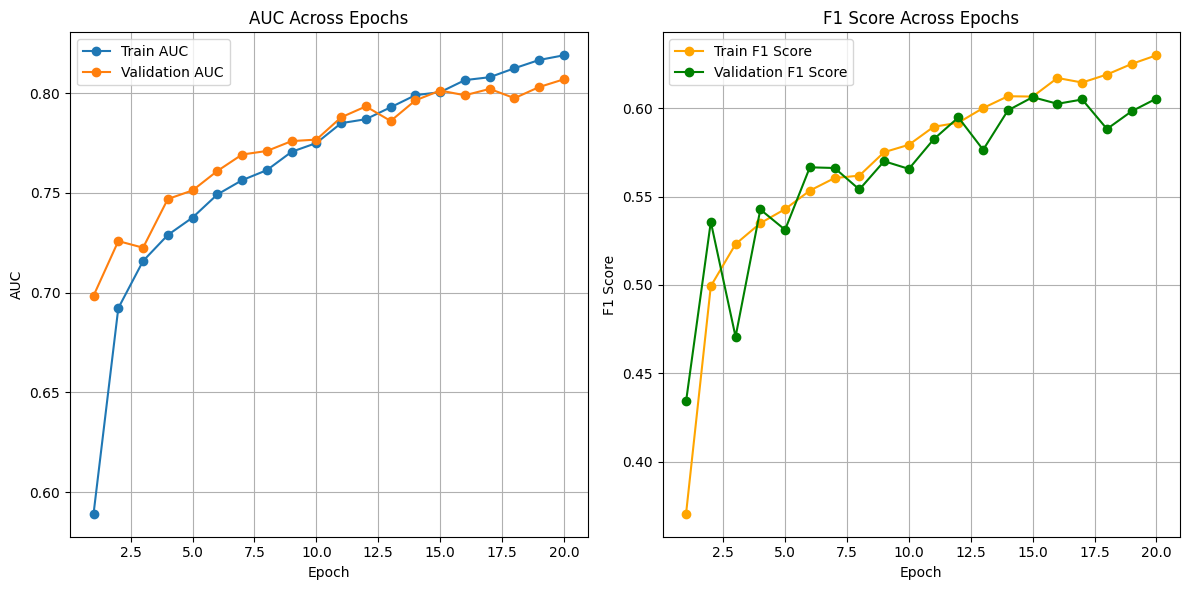

In [ ]:
plot_metrics(train_auc=train_metrics[0], valid_auc=valid_metrics[0], train_f1=train_metrics[1], valid_f1=valid_metrics[1], epochs=20)


              precision    recall  f1-score   support

           0       0.67      0.73      0.70      8220
           1       0.39      0.61      0.48      8167
           2       0.84      0.54      0.66     14453

    accuracy                           0.61     30840
   macro avg       0.64      0.63      0.61     30840
weighted avg       0.68      0.61      0.62     30840

AUC: 0.8102
F1 Score: 0.6115
Test Accuracy: 60.86%
Confusion Matrix:
[[6005 2036  179]
 [1902 4978 1287]
 [1074 5593 7786]]


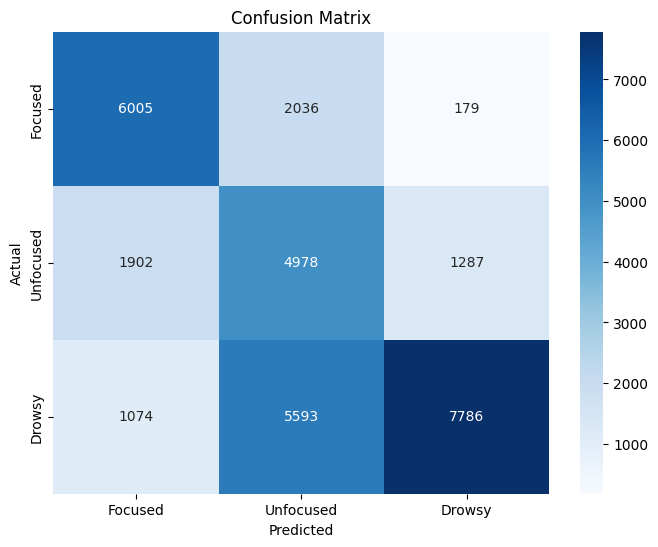

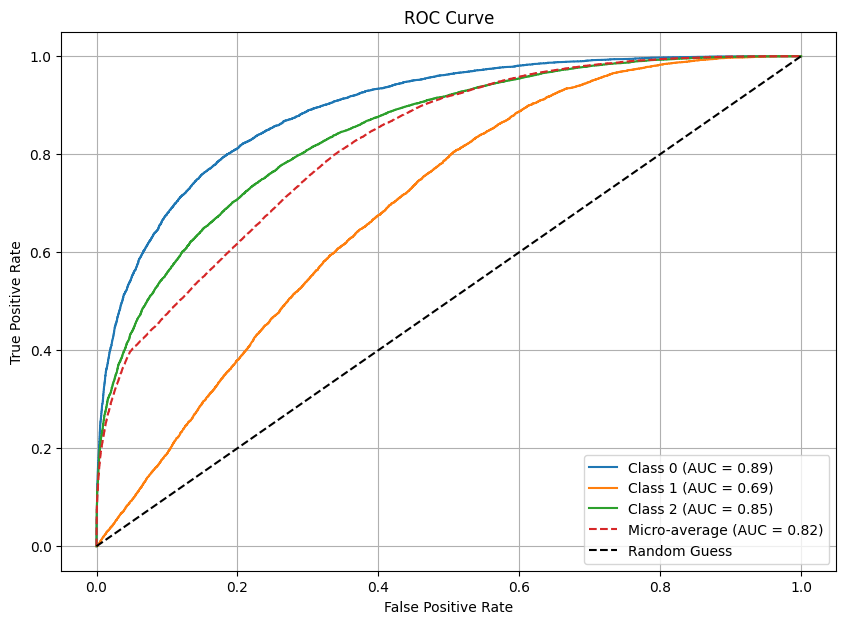

In [ ]:
plot_ROC_curves(model2,test_loader=test_loader)

**Comments**

- Overall, looking at the graph of the metrics: The model did not learn very well, as the F1_score only reached 0.65 with this imbalanced dataset. However, the AUC score is quite high, exceeding 0.8, which indicates that the model has good ability to distinguish between the 3 classes. However, when it comes to accurate classification, the model still faces challenges. This can be explained by the imbalance in the data, making it difficult to accurately classify which class a sample belongs to.

- Based on the confusion matrix: We can see that Class 1 is relatively well classified, but it is still often confused with Class 0. This could be due to the fact that the "focused" and "unfocused" states are not clearly distinguishable, especially when the "focused" state is only observed for 10 minutes. Class 2 is often confused with Class 1, which may explain why, in the "drowsy" state, many of the subjects in the experiment were not actually feeling sleepy.

- Class 0:

- The ROC curve for Class 0 is the highest among the classes, indicating that the model performs best when classifying Class 0.
- The area under the curve (AUC) is 0.89, showing that the model can distinguish between Class 0 and the other classes very well.
- Class 1:
- The ROC curve for Class 1 is the lowest compared to the other classes.
- AUC = 0.69, indicating a significantly lower discrimination performance than Class 0 and Class 2. This is because the signals from Class 1 do not have clear enough distinctions to differentiate from the other two classes.
- Class 2:
- The ROC curve for Class 2 is in between the curves for the other two classes.
- AUC = 0.85, showing that the model performs well, but not as well as Class 0.

* Train on a balanced dataset, using the oversampling method. Với phương pháp này dữ liệu của hai nhãn bị mất cân bằng sẽ bằng với số lượng của nhãn có mẫu lớn nhất. Tuy nhiên sẽ

x_train shape: (52126, 12, 128)
52126 train samples
43439 test samples
13032 valid samples
Epoch [0/20], Loss: 1.0048, Accuracy: 42.28% , AUC: 0.6436,f1:0.38
              precision    recall  f1-score   support

           0       0.65      0.56      0.60      4289
           1       0.41      0.65      0.50      4342
           2       0.63      0.35      0.45      4401

    accuracy                           0.52     13032
   macro avg       0.57      0.52      0.52     13032
weighted avg       0.56      0.52      0.52     13032

AUC: 0.7202
F1 Score: 0.5173
Test Accuracy: 51.83%
Epoch [1/20], Loss: 0.9281, Accuracy: 50.51% , AUC: 0.7118,f1:0.48
              precision    recall  f1-score   support

           0       0.67      0.58      0.63      4289
           1       0.42      0.76      0.54      4342
           2       0.78      0.26      0.39      4401

    accuracy                           0.53     13032
   macro avg       0.62      0.53      0.52     13032
weighted avg     

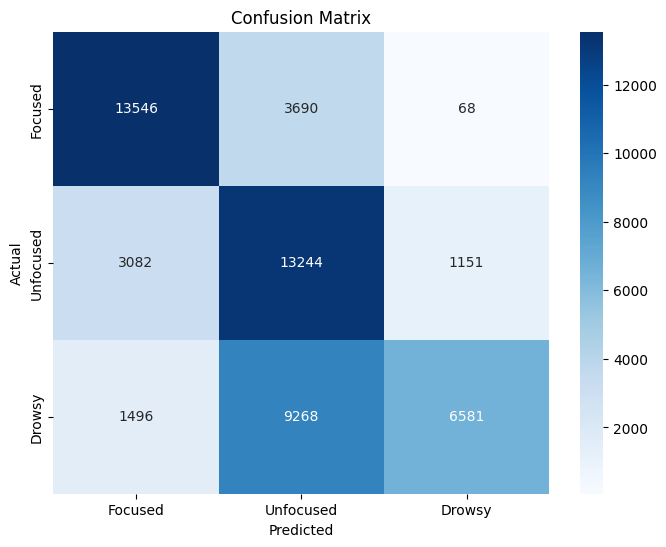

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_shape=(128,12)
num_classes = 3
epochs = 20
learning_rate = 1e-3
# Create class weights for the loss function to prevent model bias towards the class with more samples.
class_counts=count_classes(y)
class_weights = 1.0 / class_counts
class_weights = torch.tensor(class_weights / class_weights.min(), dtype=torch.float32).to(device)
# initialize dataloader
train_loader,test_loader,valid_loader=create_signal_loader(X=X_signal,y=y_signal,sampling=True)

model2=EEGNet(inp_shape=input_shape,classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model2.parameters(), lr=learning_rate,weight_decay=1e-5)

train_metrics,valid_metrics=train(model2,train_loader=train_loader,valid_loader=valid_loader,criterion=criterion,optimizer=optimizer,epochs=epochs)

x_train shape: (37007, 12, 128)
37007 train samples
30840 test samples
9252 valid samples
              precision    recall  f1-score   support

           0       0.73      0.78      0.75      8205
           1       0.42      0.76      0.54      8251
           2       0.91      0.45      0.60     14384

    accuracy                           0.62     30840
   macro avg       0.68      0.66      0.63     30840
weighted avg       0.73      0.62      0.63     30840

AUC: 0.8421
F1 Score: 0.6321
Test Accuracy: 62.10%
Confusion Matrix:
[[6381 1758   66]
 [1384 6269  598]
 [1017 6866 6501]]


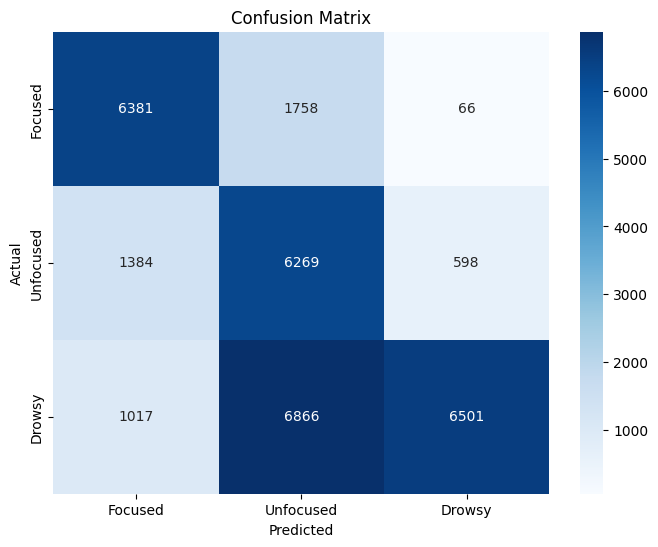

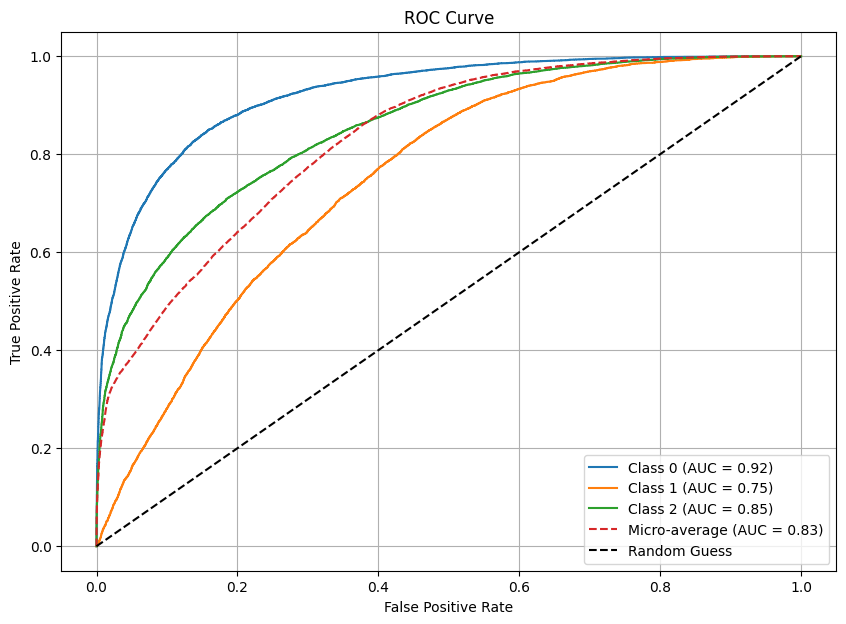

In [ ]:
# Predict on the dataset before sampling
_,test_loader,_=create_signal_loader(X=X_signal,y=y_signal,sampling=False)
plot_ROC_curves(model2,test_loader=test_loader)

**Observation**: After training on the balanced dataset and predicting back on the original dataset (without any sampling), we can see that:
- The model has performed better in classifying the "focused" and "unfocused" classes.
- The F1 score on the dataset has improved to 0.63.
- However, the model still misclassifies the "Drowsy" class as "Unfocused."
- The "Unfocused" class has been predicted more accurately as the model has focused more on this class compared to the initial model.